# TinyMNIST Classification using Custom PCA and Gaussian Naïve Bayes

This notebook implements Principal Component Analysis (PCA) from scratch on the **TinyMNIST** dataset.
The main objectives are:
1. Compute covariance matrix, eigenvalues, and eigenvectors of training data.
2. Determine optimal feature dimension ($k$) based on cumulative variance ratio.
3. Project data onto the $k$-dimensional subspace.
4. Evaluate Gaussian Naïve Bayes classifier accuracy (CCR) on test data and compare with direct feature selection.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X_train = pd.read_csv("TinyMNIST/trainData.csv", header=None).to_numpy()
X_test = pd.read_csv("TinyMNIST/testData.csv", header=None).to_numpy()
y_train = pd.read_csv("TinyMNIST/trainLabels.csv", header=None).to_numpy().ravel()
y_test = pd.read_csv("TinyMNIST/testLabels.csv", header=None).to_numpy().ravel()

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5000, 196)
Test shape: (2500, 196)


## 1. Custom PCA Implementation (Mean Centering, Covariance & Eigendecomposition)

In [2]:
mean_train = np.mean(X_train, axis=0)
X_train_centered = X_train - mean_train
X_test_centered = X_test - mean_train

cov_matrix = np.cov(X_train_centered, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
eigenvalues = np.maximum(eigenvalues, 0)

## 2. Eigenvalue Plot & Optimal Feature Selection

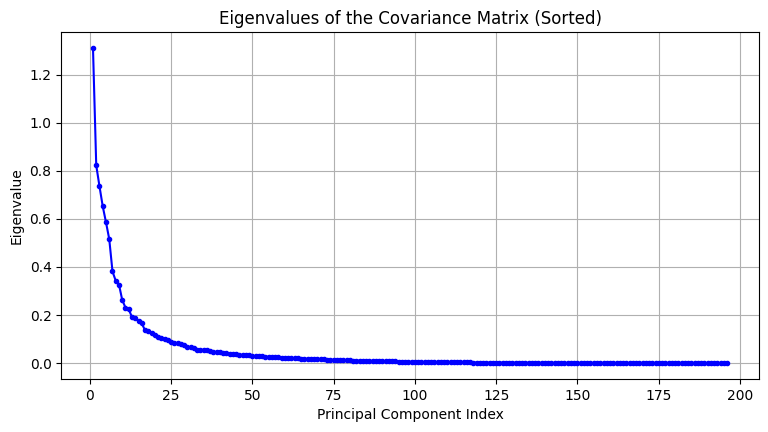

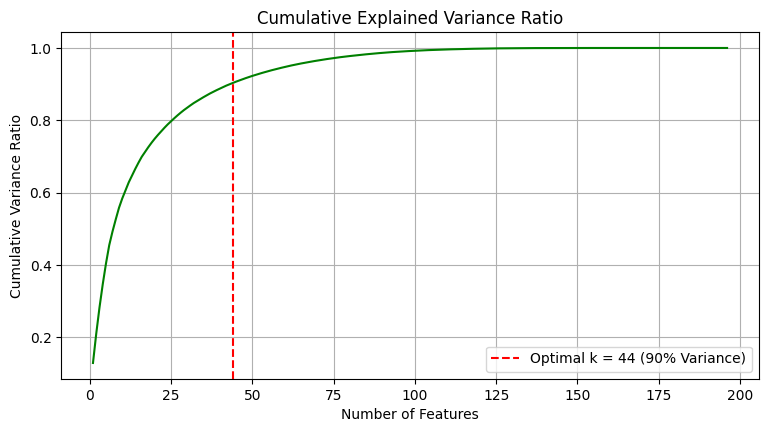

Optimal k: 44


In [3]:
plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, 'b-o', markersize=3)
plt.title('Eigenvalues of the Covariance Matrix (Sorted)')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

total_variance = np.sum(eigenvalues)
cum_var_explained_ratio = np.cumsum(eigenvalues / total_variance)
k_optimal = np.argmax(cum_var_explained_ratio >= 0.90) + 1

plt.figure(figsize=(9, 4.5))
plt.plot(np.arange(1, len(eigenvalues) + 1), cum_var_explained_ratio, 'g-')
plt.axvline(x=k_optimal, color='r', linestyle='--', label=f'Optimal k = {k_optimal} (90% Variance)')
plt.title('Cumulative Explained Variance Ratio')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()

print(f'Optimal k: {k_optimal}')

## 3. Subspace Projection & Naïve Bayes Classification

In [4]:
W_k = eigenvectors[:, :k_optimal]
X_train_pca = np.dot(X_train_centered, W_k)
X_test_pca = np.dot(X_test_centered, W_k)

gnb_clf = GaussianNB()
gnb_clf.fit(X_train_pca, y_train)
y_pred_pca = gnb_clf.predict(X_test_pca)
ccr_pca = accuracy_score(y_test, y_pred_pca)

print(f'CCR with PCA ({k_optimal} features): {ccr_pca * 100:.2f}%')

CCR with PCA (44 features): 83.12%


## 4. Discussion & Comparison
The accuracy of classification differs across feature selection methods. In PCA, we remove less information and, considering all the information, we find a direction along which we can maximize the variance of the data, thereby reducing calculations, compressing the data, and increasing time efficiency and space efficiency. From a statistical point of view, fewer dimensions will lead to better generalization.